In [18]:
!pip3 install graphviz

Defaulting to user installation because normal site-packages is not writeable


In [78]:
import math
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [18]:
def f(x):
    return 3*x**2 -4*x + 5

In [19]:
f(3)

20

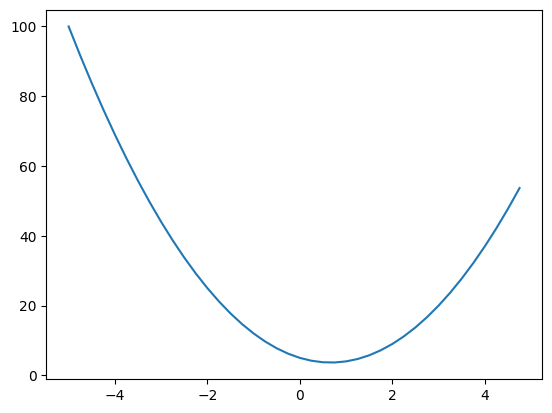

In [20]:
xs = np.arange(-5, 5, 0.25)
ys = f(xs)
plt.plot(xs, ys)

In [21]:
h = 0.00001
x = 2/3
(f(x+h) - f(x)) / h

3.0000002482211127e-05

In [22]:
a = 3
b = 4
c = 8

d = a*b + c
d

20

In [24]:
h = 0.01
a = 3
b = 4
c = 8

d1 = a*b + c
d1 += h
d2 = a*b + c

print('d1', d1)
print('d2', d2)
print('slope', (d2 - d1)/h)

d1 20.01
d2 20
slope -1.0000000000001563


In [107]:
class Value:

    def __init__(self, data, _children = (), _op = '', label = ''):
        self.data = data
        self.grad = 0.0
        self._backward = lambda: None
        self._prev = set(_children) 
        self._op = _op
        self.label = label

    def __repr__(self):
        return f"Value(data={self.data})"
    
    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data + other.data, (self, other), '+')

        def _backward():
            self.grad += 1.0 * out.grad
            other.grad += 1.0 * out.grad
        out._backward = _backward

        return out
    
    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data * other.data, (self, other), '*')

        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad
        out._backward = _backward

        return out
    
    def __pow__(self, other):
        assert isinstance(other, (int, float)), "allowed data types float/int only"
        out = Value(self.data**other, (self, ), f"**{other}")

        def _backward():
            self.grad += other * (self.data ** (other - 1)) * out.grad
        out._backward = _backward

        return out
    
    def __rmul__(self, other):
        return self * other
    
    def __truediv__(self, other):
        return self * other**-1
    
    def __neg__(self):
        return self * -1
        
    def __sub__(self, other):
        return self + (-other)
    
    def __radd__(self, other):
        return self + other
    
    def exp(self):
        x = self.data
        out = Value(math.exp(x), (self, ), 'exp')

        def _backward():
            self.grad += out.data * out.grad
        out._backward = _backward

        return out
    
    def tanh(self):
        x = self.data
        t = (math.exp(2*x) - 1) / (math.exp(2*x) + 1)
        out = Value(t, (self, ), 'tanh')

        def _backward():
            self.grad += (1 - t**2) * out.grad
        out._backward = _backward

        return out
    
    def backward(self):
        topo = []
        visited = set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
        build_topo(self)

        self.grad = 1.0
        for node in reversed(topo):
            node._backward()


In [52]:
a = Value(3.0, label='a')
b = Value(4.0, label='b')
c = Value(5.0, label='c')
d = a * b 
d.label = 'd'
e = d + c
e.label = 'e'
f = Value(6.0, label='f')
L = e * f
L.label = 'L'
L

Value(data=102.0)

In [ ]:
from graphviz import Digraph

def trace(root):
  # builds a set of all nodes and edges in a graph
  nodes, edges = set(), set()
  def build(v):
    if v not in nodes:
      nodes.add(v)
      for child in v._prev:
        edges.add((child, v))
        build(child)
  build(root)
  return nodes, edges

def draw_dot(root):
  dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR = left to right
  
  nodes, edges = trace(root)
  for n in nodes:
    uid = str(id(n))
    # for any value in the graph, create a rectangular ('record') node for it
    dot.node(name = uid, label = "{ %s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad), shape='record')
    if n._op:
      # if this value is a result of some operation, create an op node for it
      dot.node(name = uid + n._op, label = n._op)
      # and connect this node to it
      dot.edge(uid + n._op, uid)

  for n1, n2 in edges:
    # connect n1 to the op node of n2
    dot.edge(str(id(n1)), str(id(n2)) + n2._op)

  return dot

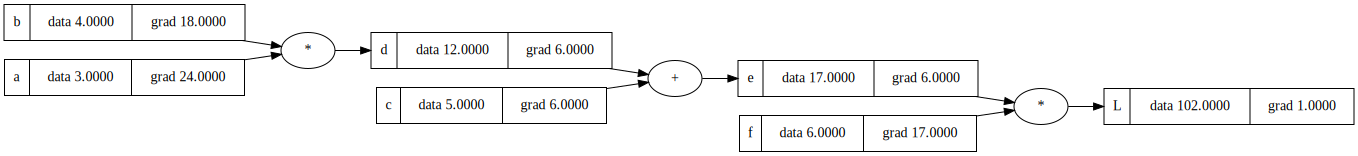

In [55]:
draw_dot(L)

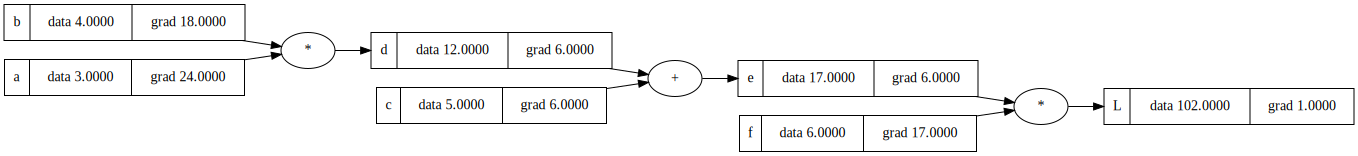

In [51]:
L.backward()
draw_dot(L)

In [54]:
#manual backpropgation
L.grad = 1.0

#dL/df
f.grad = e.data
#dL/de
e.grad = f.data

#dL/dd = dL/de * de/dd
d.grad = e.grad * 1.0
#dL/dc = dL/de * de/dc
c.grad = e.grad * 1.0

#dL/db = dL/dd * dd/db
b.grad = d.grad * a.data
#dL/da = dL/dd * dd/da
a.grad = d.grad * b.data

In [98]:
#check manual backpropgation
def check():
    h = 0.001

    a = Value(3.0, label='a')
    b = Value(4.0, label='b')
    c = Value(5.0, label='c')
    d = a * b 
    d.label = 'd'
    e = d + c
    e.label = 'e'
    f = Value(6.0, label='f')
    L = e * f
    L.label = 'L'
    L1 = L.data

    a = Value(3.0 + h, label='a')
    b = Value(4.0, label='b')
    c = Value(5.0, label='c')
    d = a * b 
    d.label = 'd'
    e = d + c
    e.label = 'e'
    f = Value(6.0, label='f')
    L = e * f
    L.label = 'L'
    L2 = L.data

    print((L2 - L1) / h)

check()

23.9999999999867


In [105]:
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')

w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')

b = Value(6.8813735870195432, label='b')

x1w1 = x1 * w1; x1w1.label = 'x1*w1'
x2w2 = x2 * w2; x2w2.label = 'x2*w2'

x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'

n = x1w1x2w2 + b; n.label = 'n'
o = n.tanh(); o.label = 'o'

o.backward()

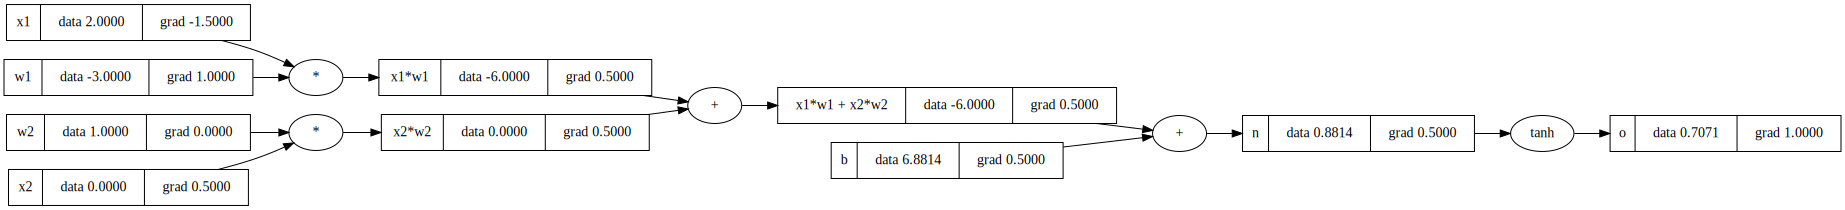

In [116]:
# inputs x1,x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
# weights w1,w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
# bias of the neuron
b = Value(6.8813735870195432, label='b')
# x1*w1 + x2*w2 + b
x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n'
o = n.tanh(); o.label = 'o'
o.backward()
draw_dot(o)

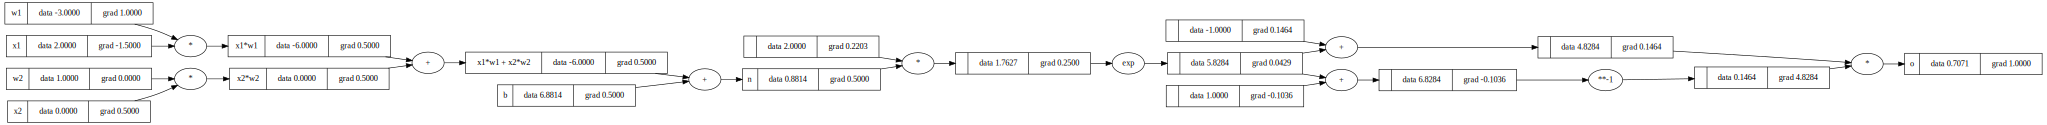

In [117]:
# inputs x1,x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
# weights w1,w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
# bias of the neuron
b = Value(6.8813735870195432, label='b')
# x1*w1 + x2*w2 + b
x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n'

e = (2*n).exp()
o = (e - 1) / (e + 1)
o.label = 'o'
o.backward()
draw_dot(o)

In [ ]:
#verify with pytorch
import torch

x1 = torch.Tensor([2.0]).double(); x1.requires_grad = True
x2 = torch.Tensor([0.0]).double(); x2.requires_grad = True

w1 = torch.Tensor([-3.0]).double(); w1.requires_grad = True
w2 = torch.Tensor([1.0]).double(); w2.requires_grad = True

b = torch.Tensor([6.8813735870195432]); b.requires_grad = True

n = x1*w1 + x2*w2 + b
o = torch.tanh(n)

print(o.data.item())
o.backward()

print('w2', w2.grad)
print('w1', w1.grad)
print('x1', x1.grad)
print('x2', x2.grad)

0.7071066904050358
w2 tensor([0.], dtype=torch.float64)
w1 tensor([1.0000], dtype=torch.float64)
x1 tensor([-1.5000], dtype=torch.float64)
x2 tensor([0.5000], dtype=torch.float64)
